<a href="https://colab.research.google.com/github/Nik8x/Sentiment140/blob/master/Sentiment140.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![alt text](http://help.sentiment140.com/_/rsrc/1472844971973/config/customLogo.gif?revision=2)

[Sentiment140 link](http://help.sentiment140.com/for-students/)

In [11]:
!ls

sample_data			training.1600000.processed.noemoticon.csv
testdata.manual.2009.06.14.csv


In [46]:
!du -h training.1600000.processed.noemoticon.csv
!du -h testdata.manual.2009.06.14.csv

228M	training.1600000.processed.noemoticon.csv
76K	testdata.manual.2009.06.14.csv


In [5]:
!head -n 5 training.1600000.processed.noemoticon.csv

"0","1467810369","Mon Apr 06 22:19:45 PDT 2009","NO_QUERY","_TheSpecialOne_","@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"
"0","1467810672","Mon Apr 06 22:19:49 PDT 2009","NO_QUERY","scotthamilton","is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!"
"0","1467810917","Mon Apr 06 22:19:53 PDT 2009","NO_QUERY","mattycus","@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds"
"0","1467811184","Mon Apr 06 22:19:57 PDT 2009","NO_QUERY","ElleCTF","my whole body feels itchy and like its on fire "
"0","1467811193","Mon Apr 06 22:19:57 PDT 2009","NO_QUERY","Karoli","@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. "


In [15]:
!head -n 2 testdata.manual.2009.06.14.csv

"4","3","Mon May 11 03:17:40 UTC 2009","kindle2","tpryan","@stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right."
"4","4","Mon May 11 03:18:03 UTC 2009","kindle2","vcu451","Reading my kindle2...  Love it... Lee childs is good read."


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import regular expression module
import re

# bag-of-words model is one of the feature extraction algorithms for text
from sklearn.feature_extraction.text import CountVectorizer

from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import Conv1D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.utils import to_categorical
from keras.layers import Dense, Dropout, Activation

In [9]:
tweet_train_original = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding='latin-1', header = None)
tweet_train_original.columns = ['Sentiment', 'id', 'Date', 'Query', 'Username', 'Text']
tweet_train = tweet_train_original
tweet_train.head()

,Sentiment,id,Date,Query,Username,Text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [10]:
tweet_train.Sentiment.value_counts()

4    800000
0    800000
Name: Sentiment, dtype: int64

In [16]:
tweet_test_original = pd.read_csv('testdata.manual.2009.06.14.csv', encoding='latin-1', header = None)
tweet_test_original.columns = ['Sentiment', 'id', 'Date', 'Query', 'Username', 'Text']
tweet_test = tweet_test_original
tweet_test.head()

,Sentiment,id,Date,Query,Username,Text
0,4,3,Mon May 11 03:17:40 UTC 2009,kindle2,tpryan,@stellargirl I loooooooovvvvvveee my Kindle2. ...
1,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs i...
2,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fuck..."
3,4,6,Mon May 11 03:19:04 UTC 2009,kindle2,SIX15,@kenburbary You'll love your Kindle2. I've had...
4,4,7,Mon May 11 03:21:41 UTC 2009,kindle2,yamarama,@mikefish Fair enough. But i have the Kindle2...


In [44]:
tweet_test.Sentiment.value_counts()

4    182
0    177
2    139
Name: Sentiment, dtype: int64

In [17]:
tweet_train.shape, tweet_test.shape

((1600000, 6), (498, 6))

In [18]:
tweet_train.Text.head(6)

0    @switchfoot http://twitpic.com/2y1zl - Awww, t...
1    is upset that he can't update his Facebook by ...
2    @Kenichan I dived many times for the ball. Man...
3      my whole body feels itchy and like its on fire 
4    @nationwideclass no, it's not behaving at all....
5                        @Kwesidei not the whole crew 
Name: Text, dtype: object

I cannot read every tweet, so I will create a Word Cloud to see the most relevant words!

In [0]:
from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS)

def twitter_wordcloud(data):
    wordcloud = WordCloud(
        background_color='white',
        stopwords = stopwords,
        max_words = 200,
        max_font_size = 30,
        scale = 3,
        random_state = 1234
    ).generate(str(data))
    fig = plt.figure(1, figsize=(15,15))
    plt.axis('off')
    plt.imshow(wordcloud)
    plt.show()

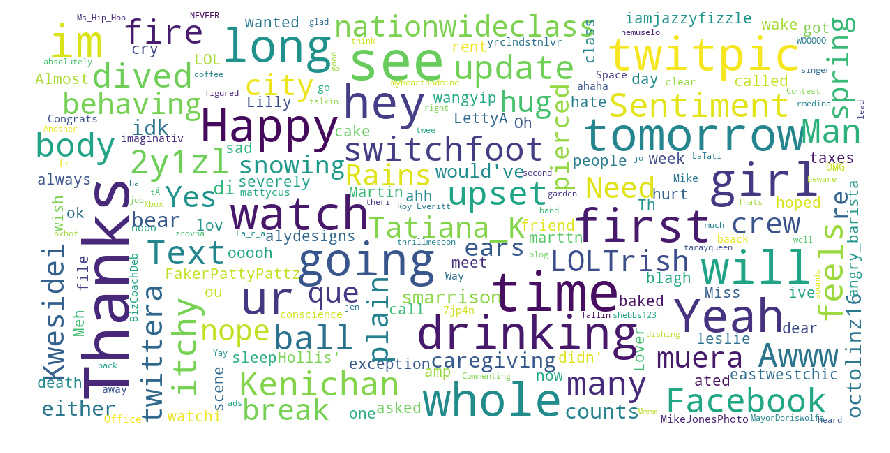

In [43]:
twitter_wordcloud(tweet_train[["Sentiment", "Text"]])

We can see positive sentiments like “Thanks”, “Happy”, "Awww" and negative sentiments like "Upset", "itchy", "ahh". 

In [0]:
twitter_wordcloud(tweet_train[["Sentiment", "Text"]])

In [0]:
def clean(tweets):
    
    # remove user names
    tweets_clean = tweets.str.replace(r'@.*? ','')
    tweets_clean = tweets_clean.str.replace(r'@\_.*? ','')
    
    # remove links
    tweets_clean = tweets_clean.str.replace(r'http://.*?($| )', '')
    
    # remove quotes
    tweets_clean = tweets_clean.replace('"','')
    tweets_clean = tweets_clean.replace("'",'')
    
    # other
    tweets_clean = tweets_clean.replace('  ',' ')
    tweets_clean = tweets_clean.replace('&lt;','<')
    tweets_clean = tweets_clean.replace('&gt;','>')
    
    # remove leading edge spacing
    tweets_clean = tweets_clean.str.replace(r'^ +','')
    
    # make everything lowercase
    tweets_clean = tweets_clean.str.lower()
    return tweets_clean

In [0]:
tweets = clean(tweet_train.Text)

In [0]:
vectorizer = CountVectorizer(ngram_range=(1, 5))

In [0]:
tweets_vector = vectorizer.fit_transform(tweets)#.todense()
#tweets_vector_1 = vectorizer.fit_transform(tweets[100001:200000]).todense()
#print( vectorizer.vocabulary_ )

In [0]:
tweets_vector.shape

(1600000, 36844338)

tweets_vector will be used as X_train
tweet_train.Sentiment will be used as y_train

In [0]:
dummy_train = to_categorical(tweet_train.Sentiment)

Creating the keras model

In [0]:
max_tweet_length = 15
vector_size = 512

In [0]:
model = Sequential()

In [0]:
model.add(Dense(units = 64, input_shape = (36844338,), activation = 'relu'))
#model.add(Conv1D(64, 3, border_mode='same'))
#model.add(Conv1D(32, 3, border_mode='same'))
#model.add(Conv1D(16, 3, border_mode='same'))
#model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(64,activation='sigmoid'))
model.add(Dropout(0.2))
model.add(Dense(1,activation='softmax'))

In [0]:
model.compile(loss='binary_crossentropy',
  optimizer='adam',
  metrics=['accuracy'])

In [0]:
dummy_train.reshape(dummy_train.shape).shape

(1600000, 5)

In [0]:
dummy_train.shape[0]

1600000

In [0]:
model.fit(tweets_vector, dummy_train.reshape(8000000, 1),
  batch_size=32,
  epochs=5,
  validation_split=0.1,shuffle=True)

In [0]:
tweets_vector.shape, dummy_train.shape

((1600000, 36844338), (1600000, 5))

In [0]:
dummy_train

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.]])